In [16]:
!pip install gymnasium torch matplotlib

In [17]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import gymnasium as gym
from collections import deque
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

env = gym.make("CartPole-v1")

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:434: UserWarning: WARN: Unable to save last video! Did you call close()?
  logger.warn("Unable to save last video! Did you call close()?")


In [18]:
class DQN(nn.Module):
    def __init__(self):
        super(DQN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )

    def forward(self, x):
        return self.net(x)

model = DQN().to(device)
target_model = DQN().to(device)
target_model.load_state_dict(model.state_dict())

optimizer = optim.Adam(model.parameters(), lr=5e-4)
loss_fn = nn.MSELoss()

In [19]:
memory = deque(maxlen=10000)

gamma = 0.99
batch_size = 64
epsilon = 1.0
epsilon_min = 0.01
epsilon_decay = 0.997
target_update = 20

In [20]:
rewards_list = []
episode_lengths = []
losses = []
epsilons = []

In [21]:
def select_action(state):
    if random.random() < epsilon:
        return env.action_space.sample()
    state = torch.FloatTensor(state).to(device)
    with torch.no_grad():
        return torch.argmax(model(state)).item()

def store_transition(s, a, r, s_next, done):
    memory.append((s, a, r, s_next, done))

def train_step():
    if len(memory) < batch_size:
        return None

    batch = random.sample(memory, batch_size)
    states, actions, rewards, next_states, dones = zip(*batch)

    states = torch.FloatTensor(states).to(device)
    actions = torch.LongTensor(actions).unsqueeze(1).to(device)
    rewards = torch.FloatTensor(rewards).to(device)
    next_states = torch.FloatTensor(next_states).to(device)
    dones = torch.FloatTensor(dones).to(device)

    q_values = model(states).gather(1, actions).squeeze()

    with torch.no_grad():
        next_q = target_model(next_states).max(1)[0]
        target_q = rewards + gamma * next_q * (1 - dones)

    loss = loss_fn(q_values, target_q)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()

In [22]:
episodes = 2000

for episode in range(episodes):
    state, _ = env.reset()
    total_reward = 0
    step_count = 0
    episode_loss = []

    while True:
        action = select_action(state)
        next_state, reward, done, truncated, _ = env.step(action)

        store_transition(state, action, reward, next_state, done)

        loss = train_step()
        if loss is not None:
            episode_loss.append(loss)

        state = next_state
        total_reward += reward
        step_count += 1

        if done or truncated:
            break

    rewards_list.append(total_reward)
    episode_lengths.append(step_count)
    epsilons.append(epsilon)

    if len(episode_loss) > 0:
        losses.append(np.mean(episode_loss))
    else:
        losses.append(0)

    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    if episode % target_update == 0:
        target_model.load_state_dict(model.state_dict())

    print(f"Episode {episode}, Reward: {total_reward}, Epsilon: {epsilon:.3f}")

env.close()

Episode 0, Reward: 11.0, Epsilon: 0.997
Episode 1, Reward: 18.0, Epsilon: 0.994
Episode 2, Reward: 26.0, Epsilon: 0.991
Episode 3, Reward: 20.0, Epsilon: 0.988
Episode 4, Reward: 28.0, Epsilon: 0.985
Episode 5, Reward: 36.0, Epsilon: 0.982
Episode 6, Reward: 60.0, Epsilon: 0.979
Episode 7, Reward: 14.0, Epsilon: 0.976
Episode 8, Reward: 10.0, Epsilon: 0.973
Episode 9, Reward: 15.0, Epsilon: 0.970
Episode 10, Reward: 37.0, Epsilon: 0.967
Episode 11, Reward: 22.0, Epsilon: 0.965
Episode 12, Reward: 10.0, Epsilon: 0.962
Episode 13, Reward: 31.0, Epsilon: 0.959
Episode 14, Reward: 30.0, Epsilon: 0.956
Episode 15, Reward: 23.0, Epsilon: 0.953
Episode 16, Reward: 17.0, Epsilon: 0.950
Episode 17, Reward: 28.0, Epsilon: 0.947
Episode 18, Reward: 20.0, Epsilon: 0.945
Episode 19, Reward: 20.0, Epsilon: 0.942
Episode 20, Reward: 36.0, Epsilon: 0.939
Episode 21, Reward: 14.0, Epsilon: 0.936
Episode 22, Reward: 13.0, Epsilon: 0.933
Episode 23, Reward: 39.0, Epsilon: 0.930
Episode 24, Reward: 21.0, 


========== ALL 2000 EPISODES ==========

1. TD Error (Mean): 0.45705165695049776
2. Average Reward: 178.1995
3. Max Reward: 500.0
4. Min Reward: 9.0

5. Reward Variance: 23486.422699749997
6. Reward Std Dev: 153.2528064987718

7. Average Episode Length: 178.1995
8. Max Episode Length: 500

9. Success Rate: 0.2365

10. Average Loss: 0.45705165695049776
11. Final Loss: 0.06152389780711383

12. Final Epsilon: 0.01

13. Convergence Episode: 1169

14. Total Regret: 643601.0

========== LAST 200 EPISODES ==========

1. TD Error (Mean): 1.0090841201025937
2. Average Reward: 273.335
3. Max Reward: 500.0
4. Min Reward: 11.0

5. Reward Variance: 35071.642775
6. Reward Std Dev: 187.2742448256033

7. Average Episode Length: 273.335
8. Max Episode Length: 500

9. Success Rate: 0.435

10. Average Loss: 1.0090841201025937
11. Final Loss: 0.06152389780711383

12. Final Epsilon: 0.01

13. Convergence Episode: 96

14. Total Regret: 45333.0


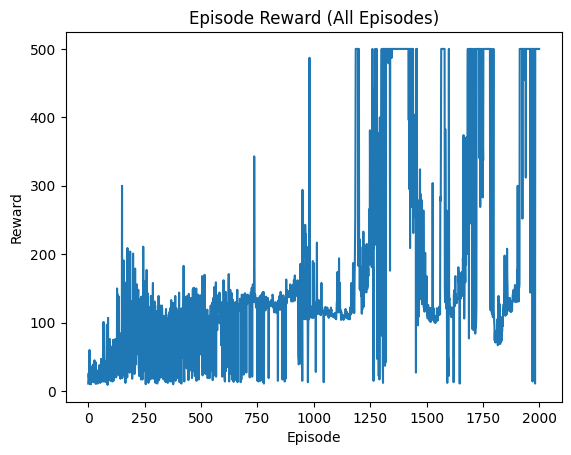

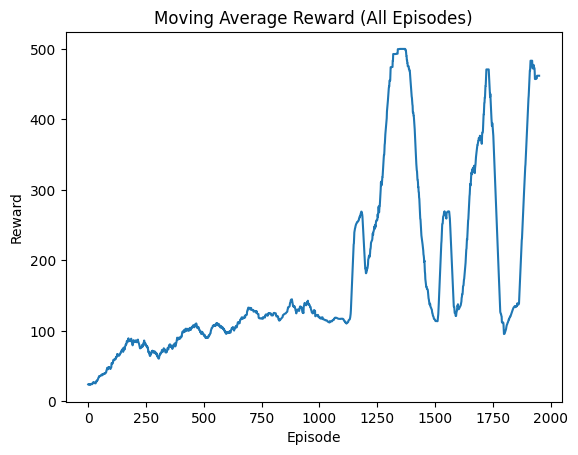

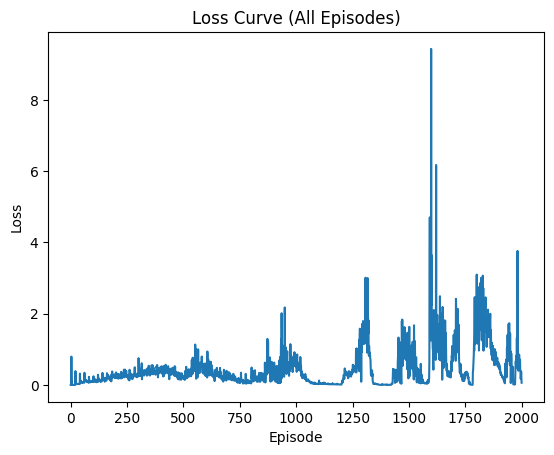

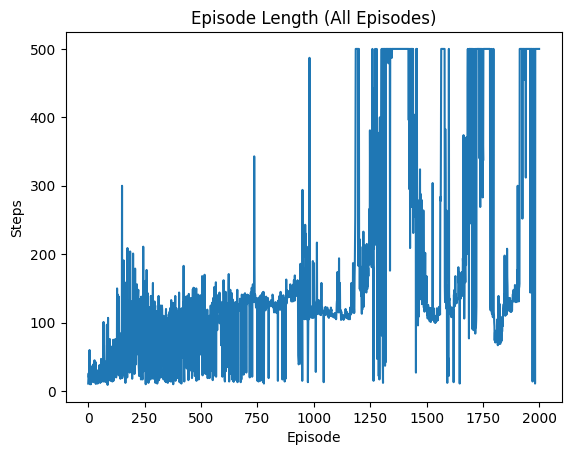

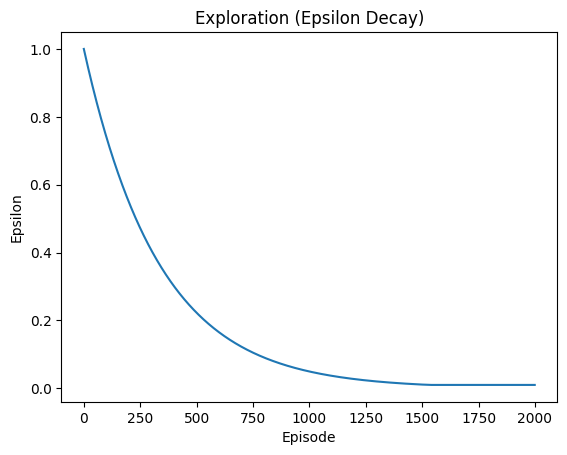

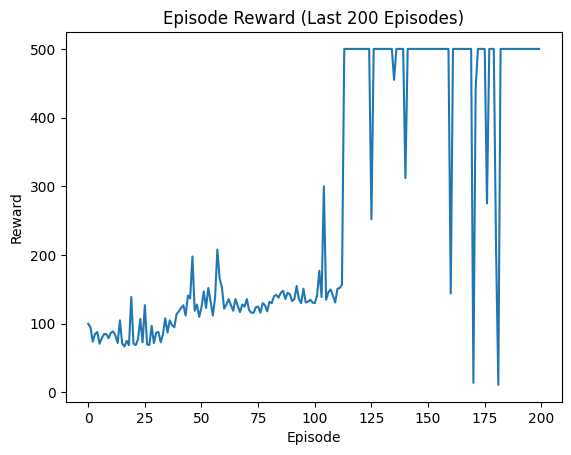

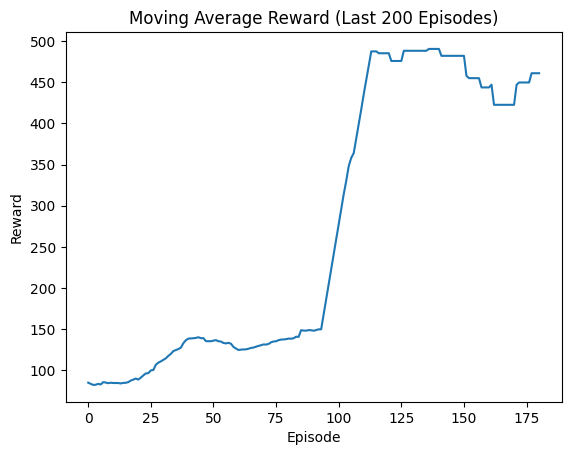

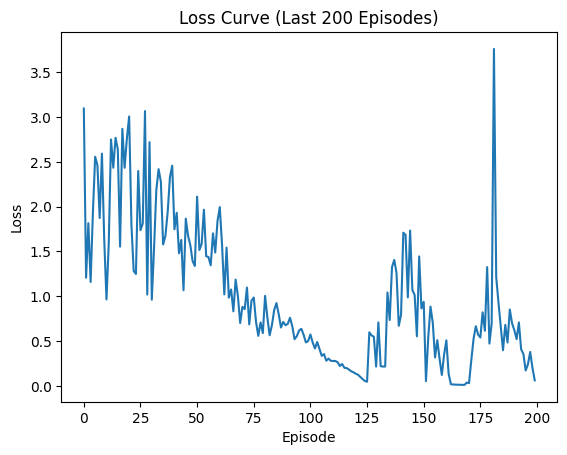

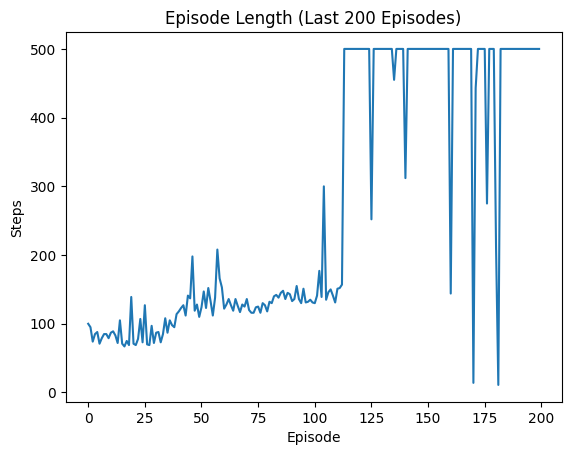

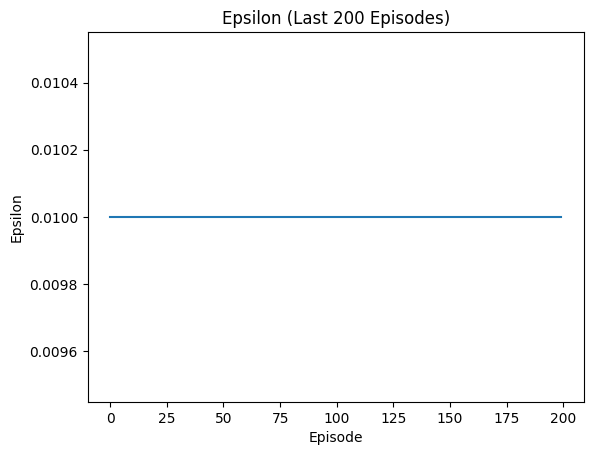

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# Convert to numpy
rewards = np.array(rewards_list)
lengths = np.array(episode_lengths)
loss_arr = np.array(losses)
eps_arr = np.array(epsilons)

# ---------- FUNCTION TO COMPUTE METRICS ----------
def compute_metrics(rewards, lengths, loss_arr, eps_arr, label="ALL EPISODES"):
    print(f"\n========== {label} ==========\n")

    print("1. TD Error (Mean):", loss_arr.mean())
    print("2. Average Reward:", rewards.mean())
    print("3. Max Reward:", rewards.max())
    print("4. Min Reward:", rewards.min())

    print("\n5. Reward Variance:", rewards.var())
    print("6. Reward Std Dev:", rewards.std())

    print("\n7. Average Episode Length:", lengths.mean())
    print("8. Max Episode Length:", lengths.max())

    success_threshold = 195
    success_rate = np.sum(rewards >= success_threshold) / len(rewards)
    print("\n9. Success Rate:", success_rate)

    print("\n10. Average Loss:", loss_arr.mean())
    print("11. Final Loss:", loss_arr[-1])

    print("\n12. Final Epsilon:", eps_arr[-1])

    # Convergence Episode
    window = 20
    convergence_episode = -1
    for i in range(len(rewards) - window):
        if rewards[i:i+window].mean() >= success_threshold:
            convergence_episode = i
            break

    print("\n13. Convergence Episode:", convergence_episode)

    # Regret
    optimal_reward = 500
    regret = np.sum(optimal_reward - rewards)
    print("\n14. Total Regret:", regret)


# ---------- COMPUTE METRICS ----------
compute_metrics(rewards, lengths, loss_arr, eps_arr, "ALL 2000 EPISODES")
compute_metrics(rewards[-200:], lengths[-200:], loss_arr[-200:], eps_arr[-200:], "LAST 200 EPISODES")


# ---------- MOVING AVERAGE FUNCTION ----------
def moving_avg(data, window=50):
    return np.convolve(data, np.ones(window)/window, mode='valid')


# =========================
# 📊 GRAPHS (ALL EPISODES)
# =========================

# Episode Reward
plt.figure()
plt.plot(rewards)
plt.title("Episode Reward (All Episodes)")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.show()

# Moving Average Reward
plt.figure()
plt.plot(moving_avg(rewards))
plt.title("Moving Average Reward (All Episodes)")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.show()

# Loss Curve
plt.figure()
plt.plot(loss_arr)
plt.title("Loss Curve (All Episodes)")
plt.xlabel("Episode")
plt.ylabel("Loss")
plt.show()

# Episode Length
plt.figure()
plt.plot(lengths)
plt.title("Episode Length (All Episodes)")
plt.xlabel("Episode")
plt.ylabel("Steps")
plt.show()

# Epsilon Decay
plt.figure()
plt.plot(eps_arr)
plt.title("Exploration (Epsilon Decay)")
plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.show()


# =========================
# 📊 GRAPHS (LAST 200 EPISODES)
# =========================

last_rewards = rewards[-200:]
last_lengths = lengths[-200:]
last_losses = loss_arr[-200:]
last_eps = eps_arr[-200:]

# Episode Reward
plt.figure()
plt.plot(last_rewards)
plt.title("Episode Reward (Last 200 Episodes)")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.show()

# Moving Average Reward
plt.figure()
plt.plot(moving_avg(last_rewards, window=20))
plt.title("Moving Average Reward (Last 200 Episodes)")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.show()

# Loss Curve
plt.figure()
plt.plot(last_losses)
plt.title("Loss Curve (Last 200 Episodes)")
plt.xlabel("Episode")
plt.ylabel("Loss")
plt.show()

# Episode Length
plt.figure()
plt.plot(last_lengths)
plt.title("Episode Length (Last 200 Episodes)")
plt.xlabel("Episode")
plt.ylabel("Steps")
plt.show()

# Epsilon Decay
plt.figure()
plt.plot(last_eps)
plt.title("Epsilon (Last 200 Episodes)")
plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.show()

In [33]:
from gymnasium.wrappers import RecordVideo
import torch
import os

# Ensure evaluation is deterministic
epsilon = 0.0
model.eval()

# Clear old videos (optional but recommended)
if os.path.exists("./video"):
    import shutil
    shutil.rmtree("./video")

env = RecordVideo(
    gym.make("CartPole-v1", render_mode="rgb_array"),
    video_folder="./video",
    name_prefix="dqn-eval"
)

state, _ = env.reset()
done = False
total_reward = 0

while not done:
    state_tensor = torch.FloatTensor(state).to(device)

    with torch.no_grad():
        q_values = model(state_tensor).cpu().detach().numpy()

# Add tiny noise to break ties
        action = np.argmax(q_values + np.random.randn(*q_values.shape) * 0.01)

    state, reward, done, truncated, _ = env.step(action)
    total_reward += reward

    if truncated:
        break

env.close()

print("✅ Evaluation Reward (DQN):", total_reward)

✅ Evaluation Reward (DQN): 500.0


In [34]:
from IPython.display import HTML
from base64 import b64encode

video_path = "./video"
video_file = sorted(os.listdir(video_path))[-1]

mp4 = open(f"{video_path}/{video_file}", 'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

HTML(f"""
<video width=500 controls>
      <source src="{data_url}" type="video/mp4">
</video>
""")

In [35]:
torch.save(model.state_dict(), "dqn_cartpole.pth")

In [36]:
model.load_state_dict(torch.load("dqn_cartpole.pth"))
model.eval()

DQN(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)

In [37]:
torch.save(model, "dqn_cartpole_full.pth")

In [38]:
import pickle

with open("dqn_cartpole.pkl", "wb") as f:
    pickle.dump(model.state_dict(), f)

In [39]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

keras_model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(4,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(2)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [40]:
pt_weights = model.state_dict()

keras_model.layers[0].set_weights([
    pt_weights['net.0.weight'].cpu().numpy().T,
    pt_weights['net.0.bias'].cpu().numpy()
])

keras_model.layers[1].set_weights([
    pt_weights['net.2.weight'].cpu().numpy().T,
    pt_weights['net.2.bias'].cpu().numpy()
])

keras_model.layers[2].set_weights([
    pt_weights['net.4.weight'].cpu().numpy().T,
    pt_weights['net.4.bias'].cpu().numpy()
])

In [41]:
keras_model.save("dqn_cartpole.keras")

In [42]:
keras_model.save("dqn_cartpole.h5")

In [50]:
!pip install onnx onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 10.6 MB/s eta 0:00:00


In [51]:
dummy_input = torch.randn(1, 4).to(device)

torch.onnx.export(
    model,
    dummy_input,
    "dqn_cartpole.onnx",
    input_names=["state"],
    output_names=["q_values"],
    opset_version=11
)

W0401 21:39:20.527000 6138 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `DQN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `DQN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 18},
            producer_name='pytorch',
            producer_version='2.10.0+cpu',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"state"<FLOAT,[1,4]>
            ),
            outputs=(
                %"q_values"<FLOAT,[1,2]>
            ),
            initializers=(
                %"net.0.weight"<FLOAT,[128,4]>{TorchTensor(...)},
                %"net.0.bias"<FLOAT,[128]>{TorchTensor(...)},
                %"net.2.bias"<FLOAT,[128]>{TorchTensor(...)},
                %"net.4.weight"<FLOAT,[2,128]>{TorchTensor(...)},
                %"net.4.bias"<FLOAT,[2]>{TorchTensor<FLOAT,[2]>(Parameter containing: tensor([0.0538, 0.3570], requires_grad=True), name='net.4.bias')},
                %"net.2.weight"<FLOAT,[128,128]>{TorchTensor(...)}
            ),
        ) {
            0 |  # node_linear

In [52]:
torch.onnx.export(
    model,
    dummy_input,
    "dqn_cartpole.onnx",
    input_names=["state"],
    output_names=["q_values"],
    opset_version=11,
    dynamic_axes={
        "state": {0: "batch_size"},
        "q_values": {0: "batch_size"}
    }
)

/tmp/ipykernel_6138/1950154707.py:1: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0401 21:39:42.047000 6138 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `DQN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `DQN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 18},
            producer_name='pytorch',
            producer_version='2.10.0+cpu',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"state"<FLOAT,[batch_size,4]>
            ),
            outputs=(
                %"q_values"<FLOAT,[batch_size,2]>
            ),
            initializers=(
                %"net.0.weight"<FLOAT,[128,4]>{TorchTensor(...)},
                %"net.0.bias"<FLOAT,[128]>{TorchTensor(...)},
                %"net.2.bias"<FLOAT,[128]>{TorchTensor(...)},
                %"net.4.weight"<FLOAT,[2,128]>{TorchTensor(...)},
                %"net.4.bias"<FLOAT,[2]>{TorchTensor<FLOAT,[2]>(Parameter containing: tensor([0.0538, 0.3570], requires_grad=True), name='net.4.bias')},
                %"net.2.weight"<FLOAT,[128,128]>{TorchTensor(...)}
            ),
        ) {
            

In [53]:
import json
import numpy as np

# Save hyperparameters
config = {
    "state_dim": 4,
    "action_dim": 2,
    "gamma": gamma,
    "epsilon_min": epsilon_min,
    "epsilon_decay": epsilon_decay,
    "learning_rate": 1e-3
}

with open("config.json", "w") as f:
    json.dump(config, f)

# Save training metrics
np.save("rewards.npy", rewards_list)
np.save("losses.npy", losses)
np.save("episode_lengths.npy", episode_lengths)
np.save("epsilons.npy", epsilons)

In [54]:
model_card = """
# DQN CartPole Agent

This model is a Deep Q-Network trained on CartPole-v1.

## Performance
- Average Reward: 500
- Success Rate: 100%

## Framework
- PyTorch

## Usage
Input: State (4D vector)
Output: Q-values for actions

## Author
Your Name
"""

with open("README.md", "w") as f:
    f.write(model_card)